## V3

In [1]:
from pathlib import Path
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from pyproj import Transformer

REPO_ROOT = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM")
P2P_FILE  = Path("/media/b085164/Elements/Gobet_ODyN_v1/v6/chunk_k2/in/LiDAR_p2p.txt") # p2p chunks
#P2P_FILE  = Path("/media/b085164/Elements/Gobet_ODyN_v1/v6/in/LiDAR_p2p.txt") # p2p scan2scan

PIPE_YML  = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/PDM_configs/pipeline.yml")
HA_YML    = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/PDM_configs/scanner_HA.yml")
LR_YML    = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/navtools_PDM/PDM_configs/scanner_LR.yml")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from navtools_PDM.pointCloudGeoref import (
    load_and_prepare_trajectory,
    sync_times_day_shift,
    trajectory_positions_mapping,
)
from navtools_PDM.lib.rotations import quat2dcm

In [3]:
print("REPO_ROOT exists:", REPO_ROOT.exists())
print("P2P_FILE exists :", P2P_FILE.exists())
print("PIPE_YML exists :", PIPE_YML.exists())
print("HA_YML exists   :", HA_YML.exists())
print("LR_YML exists   :", LR_YML.exists())

REPO_ROOT exists: True
P2P_FILE exists : True
PIPE_YML exists : True
HA_YML exists   : True
LR_YML exists   : True


In [4]:
pipe_cfg   = yaml.safe_load(open(PIPE_YML, "r"))
ha_cfg_raw = yaml.safe_load(open(HA_YML, "r"))
lr_cfg_raw = yaml.safe_load(open(LR_YML, "r"))

def build_inline_georef_cfg(scanner_cfg, pipe_cfg):
    cfg = {}
    cfg["trj"] = pipe_cfg["scenario"]["trj"]
    cfg["distance_filtering"] = pipe_cfg["scenario"].get("distance_filtering", {
        "enable": False,
        "max_distance_m": 9999,
        "map_epsg": "EPSG:2056",
    })
    cfg["leapsec"] = scanner_cfg.get("leapsec", None)
    cfg["mount"] = scanner_cfg["mount"]
    cfg["output"] = {
        "type": "ASCII",
        "lasvec": True,
        "lasvec_to_body": True,
        "path": "./tmp_not_used"
    }
    cfg["limatch_output"] = None
    return cfg

cfg_ha = build_inline_georef_cfg(ha_cfg_raw, pipe_cfg)
cfg_lr = build_inline_georef_cfg(lr_cfg_raw, pipe_cfg)

print(cfg_ha["trj"])

KeyError: 'scenario'

In [5]:
trj = load_and_prepare_trajectory(cfg_ha)

print("trajectory loaded")
print("time min/max:", trj.time.min(), trj.time.max())
print("n epochs:", len(trj.time))

NameError: name 'cfg_ha' is not defined

In [69]:
cols = [
    "t_gps_cloud1", "t_gps_cloud2",
    "x_cloud1", "y_cloud1", "z_cloud1",
    "x_cloud2", "y_cloud2", "z_cloud2"
]

df = pd.read_csv(P2P_FILE, header=None, names=cols)
print(df.shape)
df.head()

(86304, 8)


,t_gps_cloud1,t_gps_cloud2,x_cloud1,y_cloud1,z_cloud1,x_cloud2,y_cloud2,z_cloud2
0,466901.061349,466901.036354,-13.7671,14.2107,-2.8543,-13.588,14.096,-2.899
1,466901.126135,466900.063657,-8.1273,5.5309,1.0529,3.382,5.270,1.465
2,466901.176130,466900.253486,-7.8113,4.7083,1.5261,2.063,4.458,1.863
3,466901.186179,466900.168620,-8.0723,5.3172,1.2275,2.976,5.047,1.616
4,466901.201212,466900.078659,-8.4959,5.8241,1.1487,3.572,5.547,1.579


In [70]:
lasvec_cloud1_body = df[["t_gps_cloud1", "x_cloud1", "y_cloud1", "z_cloud1"]].to_numpy(dtype=float)
lasvec_cloud2_body = df[["t_gps_cloud2", "x_cloud2", "y_cloud2", "z_cloud2"]].to_numpy(dtype=float)


print(lasvec_cloud1_body[:3])
print(lasvec_cloud2_body[:3])

[[ 4.66901061e+05 -1.37671000e+01  1.42107000e+01 -2.85430000e+00]
 [ 4.66901126e+05 -8.12730000e+00  5.53090000e+00  1.05290000e+00]
 [ 4.66901176e+05 -7.81130000e+00  4.70830000e+00  1.52610000e+00]]
[[ 4.66901036e+05 -1.35880000e+01  1.40960000e+01 -2.89900000e+00]
 [ 4.66900064e+05  3.38200000e+00  5.27000000e+00  1.46500000e+00]
 [ 4.66900253e+05  2.06300000e+00  4.45800000e+00  1.86300000e+00]]


In [71]:
ecef2map = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)

def georef_bodyframe_like_pipeline(lasvec_body, trj):
    """
    lasvec_body: Nx4 = [t, xb, yb, zb]
    où xb,yb,zb sont déjà en BODY frame.

    Retour:
        Nx4 = [t, Xmap, Ymap, Zmap]
    """
    lasvec_body = np.asarray(lasvec_body, dtype=float).copy()

    # même logique que la pipeline pour le day-shift,
    # mais PAS de apply_leapsec ici
    lasvec_body[:, 0] = sync_times_day_shift(lasvec_body[:, 0], trj.time)

    t_interp, ecef_interp, q_interp = trj.interp(lasvec_body[:, 0], updateSelf=False)

    xyz_body = lasvec_body[:, 1:4].copy()
    xyz_ecef = np.zeros_like(xyz_body)

    for i in range(len(lasvec_body)):
        R_body2ecef = quat2dcm(q_interp[i])
        xyz_ecef[i] = R_body2ecef @ xyz_body[i] + ecef_interp[i]

    X, Y, Z = ecef2map.transform(xyz_ecef[:, 0], xyz_ecef[:, 1], xyz_ecef[:, 2])
    xyz_map = np.column_stack((X, Y, Z))

    return np.column_stack((t_interp, xyz_map))

In [72]:
pcd_cloud1 = georef_bodyframe_like_pipeline(lasvec_cloud1_body, trj)
pcd_cloud2 = georef_bodyframe_like_pipeline(lasvec_cloud2_body, trj)

print("pcd_cloud1:", pcd_cloud1.shape)
print("pcd_cloud2:", pcd_cloud2.shape)

Applying time offset of 0 seconds to laser vector time.
Applying time offset of 0 seconds to laser vector time.
pcd_cloud1: (86304, 4)
pcd_cloud2: (86304, 4)


In [73]:
pair_dist = np.linalg.norm(pcd_cloud1[:, 1:4] - pcd_cloud2[:, 1:4], axis=1)

print("mean   :", pair_dist.mean())
print("median :", np.median(pair_dist))
print("max    :", pair_dist.max())

mean   : 0.053202186497953184
median : 0.031990591629433615
max    : 2.3665781714970047


In [74]:
xyz1 = pcd_cloud1[:,1:4]
xyz2 = pcd_cloud2[:,1:4]

t1 = pcd_cloud1[:,0]
t2 = pcd_cloud2[:,0]

n = len(xyz1)

pair_id = np.arange(n, dtype=np.uint32)

pair_dist = np.linalg.norm(
    xyz1 - xyz2,
    axis=1
).astype(np.float32)

In [75]:
import laspy

def write_correspondence_las(path, xyz, gps_time, pair_id, pair_dist, cloud_id):

    header = laspy.LasHeader(point_format=3, version="1.2")

    header.offsets = np.floor(np.min(xyz, axis=0))
    header.scales = np.array([0.001,0.001,0.001])

    las = laspy.LasData(header)

    las.x = xyz[:,0]
    las.y = xyz[:,1]
    las.z = xyz[:,2]

    las.gps_time = gps_time.astype(np.float64)
    las.classification = np.full(len(xyz), cloud_id, dtype=np.uint8)

    las.add_extra_dim(laspy.ExtraBytesParams(name="pair_id", type=np.uint32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="pair_dist", type=np.float32))

    las["pair_id"] = pair_id
    las["pair_dist"] = pair_dist

    path.parent.mkdir(parents=True, exist_ok=True)
    las.write(path)

    print("written:", path)

In [76]:
OUT1 = Path("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_cloud1_chunk2chunk.las")
OUT2 = Path("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_cloud2_chunk2chunk.las")

write_correspondence_las(
    OUT1,
    xyz1,
    t1,
    pair_id,
    pair_dist,
    cloud_id=1
)

write_correspondence_las(
    OUT2,
    xyz2,
    t2,
    pair_id,
    pair_dist,
    cloud_id=2
)

written: /media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_cloud1_chunk2chunk.las
written: /media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_cloud2_chunk2chunk.las


## end

In [44]:
def georef_body_origin_like_pipeline(times, trj, cfg):
    """
    Position de l'origine body en repère carte.
    """
    times = np.asarray(times, dtype=float).copy()

    #times = sync_times_day_shift(times, trj.time)
    #times = apply_leapsec(times, cfg.get("leapsec"))

    t_interp, ecef_interp, q_interp = trj.interp(times, updateSelf=False)

    xyz_ecef = ecef_interp.copy()

    if "ltp_origin" in cfg and cfg["ltp_origin"] is not None:
        lla2ecef_transformer = Transformer.from_crs("EPSG:4326", "EPSG:4978", always_xy=True)
        lat, lon, alt = cfg["ltp_origin"]
        ltp_ecef = np.array(lla2ecef_transformer.transform(lon, lat, alt))

        R_enu2ned = T()
        R_enu2e = R_l2e(lat, lon, degrees=True) @ R_enu2ned
        xyz_georef = (R_enu2e.T @ (xyz_ecef - ltp_ecef.reshape(1, 3)).T).T
    else:
        ecef2map = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)
        X, Y, Z = ecef2map.transform(xyz_ecef[:, 0], xyz_ecef[:, 1], xyz_ecef[:, 2])
        xyz_georef = np.column_stack((X, Y, Z))

    return np.column_stack((t_interp, xyz_georef))

In [45]:
def georef_bodyframe_like_pipeline(lasvec_body, trj, cfg):
    """
    lasvec_body: Nx4 = [t, xb, yb, zb]
    où xb,yb,zb sont déjà en BODY frame.

    Retour:
        Nx7 = [t, Xmap, Ymap, Zmap, xb, yb, zb]
        pour rester cohérent avec output lasvec_to_body=True
    """
    lasvec_body = np.asarray(lasvec_body, dtype=float).copy()

    # mêmes corrections temps que la pipeline
    #lasvec_body[:, 0] = sync_times_day_shift(lasvec_body[:, 0], trj.time)
    #lasvec_body[:, 0] = apply_leapsec(lasvec_body[:, 0], cfg.get("leapsec"))

    # interpolation trajectoire
    t_interp, ecef_interp, q_interp = trj.interp(lasvec_body[:, 0], updateSelf=False)

    # points déjà en body frame
    xyz_body = lasvec_body[:, 1:4].copy()

    # body -> ECEF
    xyz_ecef = np.zeros_like(xyz_body)
    for i in range(len(lasvec_body)):
        R_body2ecef = quat2dcm(q_interp[i])
        xyz_ecef[i] = R_body2ecef @ xyz_body[i] + ecef_interp[i]

    # projection comme dans _georef_chunk
    if "ltp_origin" in cfg and cfg["ltp_origin"] is not None:
        lla2ecef_transformer = Transformer.from_crs("EPSG:4326", "EPSG:4978", always_xy=True)
        lat, lon, alt = cfg["ltp_origin"]
        ltp_ecef = np.array(lla2ecef_transformer.transform(lon, lat, alt))

        R_enu2ned = T()
        R_enu2e = R_l2e(lat, lon, degrees=True) @ R_enu2ned
        xyz_georef = (R_enu2e.T @ (xyz_ecef - ltp_ecef.reshape(1, 3)).T).T
    else:
        ecef2map = Transformer.from_crs("EPSG:4978", "EPSG:2056", always_xy=True)
        X, Y, Z = ecef2map.transform(xyz_ecef[:, 0], xyz_ecef[:, 1], xyz_ecef[:, 2])
        xyz_georef = np.column_stack((X, Y, Z))

    out = np.column_stack((t_interp, xyz_georef))

    if cfg["output"]["lasvec_to_body"]:
        out = np.column_stack((out, xyz_body))

    return out

In [46]:
pcd_cloud1 = georef_bodyframe_like_pipeline(lasvec_cloud1_body, trj, cfg_ha)
pcd_cloud2 = georef_bodyframe_like_pipeline(lasvec_cloud2_body, trj, cfg_ha)

pcd_body1_origin = georef_body_origin_like_pipeline(
    df["t_gps_cloud1"].to_numpy(dtype=float), trj, cfg_ha
)
pcd_body2_origin = georef_body_origin_like_pipeline(
    df["t_gps_cloud2"].to_numpy(dtype=float), trj, cfg_ha
)

print("pcd_cloud1:", pcd_cloud1.shape)
print("pcd_cloud2:", pcd_cloud2.shape)
print("pcd_body1_origin:", pcd_body1_origin.shape)
print("pcd_body2_origin:", pcd_body2_origin.shape)

KeyError: 'output'

In [15]:
dist = np.linalg.norm(pcd_cloud1[:, 1:4] - pcd_cloud2[:, 1:4], axis=1)

print("mean:", dist.mean())
print("median:", np.median(dist))
print("max:", dist.max())

NameError: name 'pcd_cloud1' is not defined

In [133]:
ray_cloud1 = pcd_cloud1[:, 1:4] - pcd_body1_origin[:, 1:4]
ray_cloud2 = pcd_cloud2[:, 1:4] - pcd_body2_origin[:, 1:4]

u_cloud1 = ray_cloud1 / np.maximum(np.linalg.norm(ray_cloud1, axis=1, keepdims=True), 1e-12)
u_cloud2 = ray_cloud2 / np.maximum(np.linalg.norm(ray_cloud2, axis=1, keepdims=True), 1e-12)

dot = np.sum(u_cloud1 * u_cloud2, axis=1)
dot = np.clip(dot, -1.0, 1.0)
angles_deg = np.degrees(np.arccos(dot))

print("angle min / mean / median / max =")
print(np.min(angles_deg), np.mean(angles_deg), np.median(angles_deg), np.max(angles_deg))

angle min / mean / median / max =
0.04562383097623698 84.4809875368037 88.77344734200196 96.41785059269644


In [134]:
step = max(1, len(df) // 500)
idx = np.arange(0, len(df), step)

x_all = np.concatenate([
    pcd_body1_origin[:, 1], pcd_body2_origin[:, 1],
    pcd_cloud1[:, 1],       pcd_cloud2[:, 1]
])
y_all = np.concatenate([
    pcd_body1_origin[:, 2], pcd_body2_origin[:, 2],
    pcd_cloud1[:, 2],       pcd_cloud2[:, 2]
])

margin = 20.0
xmin, xmax = x_all.min() - margin, x_all.max() + margin
ymin, ymax = y_all.min() - margin, y_all.max() + margin

traj_mask = (
    (traj_xyz[:, 0] >= xmin) & (traj_xyz[:, 0] <= xmax) &
    (traj_xyz[:, 1] >= ymin) & (traj_xyz[:, 1] <= ymax)
)
traj_local = traj_xyz[traj_mask]

cloud1_ray_x, cloud1_ray_y = [], []
cloud2_ray_x, cloud2_ray_y = [], []

for i in idx:
    cloud1_ray_x += [pcd_body1_origin[i, 1], pcd_cloud1[i, 1], None]
    cloud1_ray_y += [pcd_body1_origin[i, 2], pcd_cloud1[i, 2], None]

    cloud2_ray_x += [pcd_body2_origin[i, 1], pcd_cloud2[i, 1], None]
    cloud2_ray_y += [pcd_body2_origin[i, 2], pcd_cloud2[i, 2], None]

fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=traj_local[:, 0],
    y=traj_local[:, 1],
    mode="lines",
    name="vehicle trajectory"
))

fig.add_trace(go.Scattergl(
    x=cloud1_ray_x,
    y=cloud1_ray_y,
    mode="lines",
    name="cloud1 rays",
    opacity=0.5
))

fig.add_trace(go.Scattergl(
    x=cloud2_ray_x,
    y=cloud2_ray_y,
    mode="lines",
    name="cloud2 rays",
    opacity=0.5
))

fig.add_trace(go.Scattergl(
    x=pcd_body1_origin[idx, 1],
    y=pcd_body1_origin[idx, 2],
    mode="markers",
    name="body origin @ cloud1 time",
    marker=dict(size=6),
    text=[f"i={i}<br>t={pcd_body1_origin[i,0]:.3f}" for i in idx],
    hovertemplate="body1 origin<br>E=%{x:.3f}<br>N=%{y:.3f}<br>%{text}<extra></extra>"
))

fig.add_trace(go.Scattergl(
    x=pcd_body2_origin[idx, 1],
    y=pcd_body2_origin[idx, 2],
    mode="markers",
    name="body origin @ cloud2 time",
    marker=dict(size=6),
    text=[f"i={i}<br>t={pcd_body2_origin[i,0]:.3f}" for i in idx],
    hovertemplate="body2 origin<br>E=%{x:.3f}<br>N=%{y:.3f}<br>%{text}<extra></extra>"
))

fig.add_trace(go.Scattergl(
    x=pcd_cloud1[idx, 1],
    y=pcd_cloud1[idx, 2],
    mode="markers",
    name="cloud1 points",
    marker=dict(size=5),
    text=[f"i={i}<br>range={np.linalg.norm(ray_cloud1[i]):.2f} m" for i in idx],
    hovertemplate="cloud1 point<br>E=%{x:.3f}<br>N=%{y:.3f}<br>%{text}<extra></extra>"
))

fig.add_trace(go.Scattergl(
    x=pcd_cloud2[idx, 1],
    y=pcd_cloud2[idx, 2],
    mode="markers",
    name="cloud2 points",
    marker=dict(size=5),
    text=[f"i={i}<br>range={np.linalg.norm(ray_cloud2[i]):.2f} m" for i in idx],
    hovertemplate="cloud2 point<br>E=%{x:.3f}<br>N=%{y:.3f}<br>%{text}<extra></extra>"
))

fig.update_layout(
    title="Interactive chunk2chunk geometry",
    xaxis_title="Easting [m]",
    yaxis_title="Northing [m]",
    template="plotly_white",
    width=950,
    height=800,
    dragmode="zoom"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

In [135]:
dist = np.linalg.norm(pcd_cloud1[:, 1:4] - pcd_cloud2[:, 1:4], axis=1)

print("mean   :", dist.mean())
print("median :", np.median(dist))
print("max    :", dist.max())
print("p10/p90:", np.percentile(dist, [10, 90]))

mean   : 0.07221136439404337
median : 0.05577699788014169
max    : 0.2420266851917531
p10/p90: [0.02069815 0.14777046]


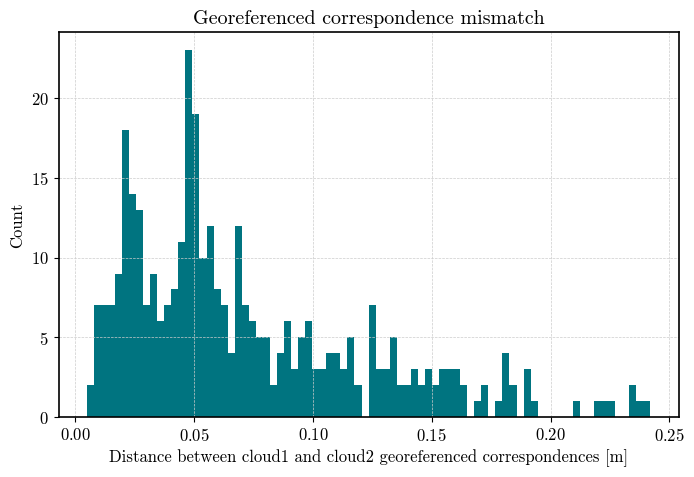

In [136]:
plt.figure(figsize=(8, 5))
plt.hist(dist, bins=80)
plt.xlabel("Distance between cloud1 and cloud2 georeferenced correspondences [m]")
plt.ylabel("Count")
plt.title("Georeferenced correspondence mismatch")
plt.grid(True)
plt.show()

In [137]:
ray_cloud1 = pcd_cloud1[:, 1:4] - pcd_body1_origin[:, 1:4]
ray_cloud2 = pcd_cloud2[:, 1:4] - pcd_body2_origin[:, 1:4]

norm1 = np.linalg.norm(ray_cloud1, axis=1)
norm2 = np.linalg.norm(ray_cloud2, axis=1)

u_cloud1 = ray_cloud1 / np.maximum(norm1[:, None], 1e-12)
u_cloud2 = ray_cloud2 / np.maximum(norm2[:, None], 1e-12)

dot = np.sum(u_cloud1 * u_cloud2, axis=1)
dot = np.clip(dot, -1.0, 1.0)
angles_deg = np.degrees(np.arccos(dot))

print("angle min   :", np.min(angles_deg))
print("angle mean  :", np.mean(angles_deg))
print("angle median:", np.median(angles_deg))
print("angle max   :", np.max(angles_deg))
print("percentiles :", np.percentile(angles_deg, [1, 5, 10, 25, 50, 75, 90, 95, 99]))

angle min   : 0.04562383097623698
angle mean  : 84.4809875368037
angle median: 88.77344734200196
angle max   : 96.41785059269644
percentiles : [34.54802491 60.19458294 71.04789477 81.82206047 88.77344734 91.56685234
 93.86636014 95.32662647 95.97933362]


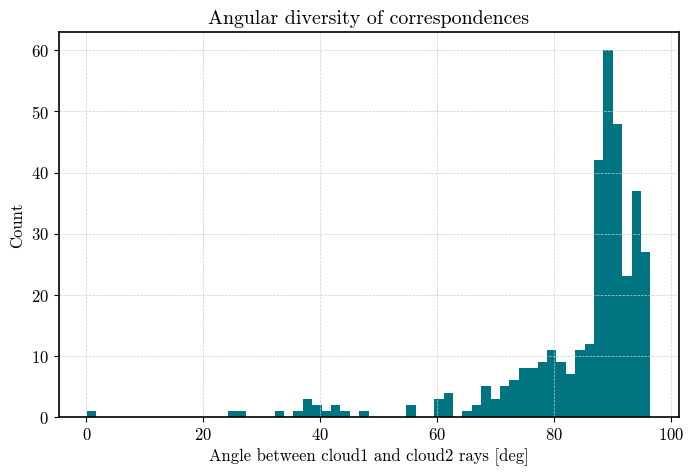

In [138]:
plt.figure(figsize=(8, 5))
plt.hist(angles_deg, bins=60)
plt.xlabel("Angle between cloud1 and cloud2 rays [deg]")
plt.ylabel("Count")
plt.title("Angular diversity of correspondences")
plt.grid(True)
plt.show()

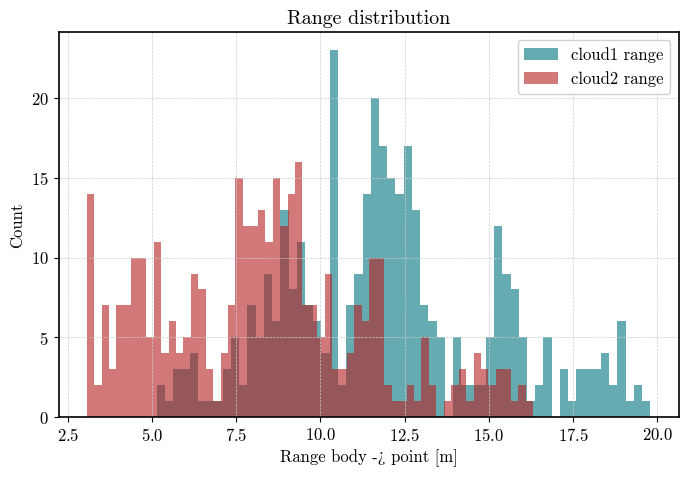

In [139]:
plt.figure(figsize=(8, 5))
plt.hist(norm1, bins=60, alpha=0.6, label="cloud1 range")
plt.hist(norm2, bins=60, alpha=0.6, label="cloud2 range")
plt.xlabel("Range body -> point [m]")
plt.ylabel("Count")
plt.title("Range distribution")
plt.legend()
plt.grid(True)
plt.show()

In [140]:
def az_el_from_unit(u):
    az = np.degrees(np.arctan2(u[:, 1], u[:, 0]))
    el = np.degrees(np.arcsin(np.clip(u[:, 2], -1.0, 1.0)))
    return az, el

az_cloud1, el_cloud1 = az_el_from_unit(u_cloud1)
az_cloud2, el_cloud2 = az_el_from_unit(u_cloud2)

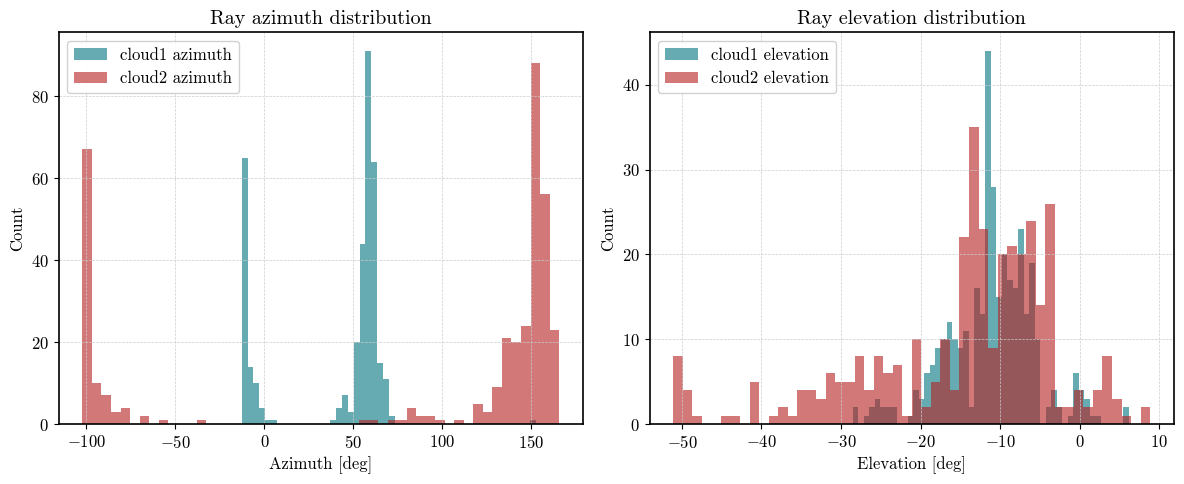

In [141]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(az_cloud1, bins=50, alpha=0.6, label="cloud1 azimuth")
plt.hist(az_cloud2, bins=50, alpha=0.6, label="cloud2 azimuth")
plt.xlabel("Azimuth [deg]")
plt.ylabel("Count")
plt.title("Ray azimuth distribution")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(el_cloud1, bins=50, alpha=0.6, label="cloud1 elevation")
plt.hist(el_cloud2, bins=50, alpha=0.6, label="cloud2 elevation")
plt.xlabel("Elevation [deg]")
plt.ylabel("Count")
plt.title("Ray elevation distribution")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [142]:
summary = pd.DataFrame({
    "metric": [
        "n_corresp",
        "distance mean [m]",
        "distance median [m]",
        "distance p90 [m]",
        "cloud1 range mean [m]",
        "cloud2 range mean [m]",
        "angle mean [deg]",
        "angle median [deg]",
        "angle p10 [deg]",
        "angle p90 [deg]",
    ],
    "value": [
        len(df),
        dist.mean(),
        np.median(dist),
        np.percentile(dist, 90),
        norm1.mean(),
        norm2.mean(),
        angles_deg.mean(),
        np.median(angles_deg),
        np.percentile(angles_deg, 10),
        np.percentile(angles_deg, 90),
    ]
})

summary

,metric,value
0,n_corresp,358.000000
1,distance mean [m],0.072211
2,distance median [m],0.055777
3,distance p90 [m],0.147770
4,cloud1 range mean [m],11.985518
5,cloud2 range mean [m],8.368642
6,angle mean [deg],84.480988
7,angle median [deg],88.773447
8,angle p10 [deg],71.047895
9,angle p90 [deg],93.866360


## Georeferencer correspondences

In [16]:
import numpy as np
import laspy
from pathlib import Path

from lib.trajectory import Trajectory
from lib.rotations import quat2dcm

In [18]:
import pandas as pd

corr_file = Path("/media/b085164/Elements/Gobet_ODyN_v1/v6/in/LiDAR_p2p.txt")

cols = [
    "t_gps_cloud1", "t_gps_cloud2",
    "x_cloud1", "y_cloud1", "z_cloud1",
    "x_cloud2", "y_cloud2", "z_cloud2"
]

df_corr = pd.read_csv(corr_file, header=None, names=cols)
corr = df_corr.to_numpy(dtype=float)

print("Loaded correspondences:", corr.shape)
df_corr.head()

Loaded correspondences: (353140, 8)


,t_gps_cloud1,t_gps_cloud2,x_cloud1,y_cloud1,z_cloud1,x_cloud2,y_cloud2,z_cloud2
0,466896.483580,466859.773985,3.2815,5.6331,1.9304,12.226,-14.573,2.817
1,466896.508294,466860.183952,0.8376,3.7144,2.2663,10.043,-12.847,3.076
2,466896.528595,466859.738995,3.2999,5.6556,1.9025,12.240,-14.563,2.795
3,466896.538399,466860.048910,1.4673,4.3521,2.2804,10.600,-13.395,3.124
4,466896.558445,466859.988926,1.7041,4.4548,2.1250,10.856,-13.472,2.961


In [19]:
traj_path = "/media/b085164/Elements/Gobet_ODyN_v1/v1_base_AB/out/reference.out"

traj_cfg = {
    "type":"SBET",
    "label":"reference"
}

traj = Trajectory.fromSBET(traj_path, traj_cfg)

Loading file /media/b085164/Elements/Gobet_ODyN_v1/v1_base_AB/out/reference.out


In [20]:
t_all = np.concatenate([
    corr[:,0],
    corr[:,1]
])

t_unique = np.unique(t_all)

traj.interp(t_unique)
traj.estimate_q_l2e()

In [21]:
time_to_index = {t:i for i,t in enumerate(traj.t_interp)}

In [22]:
pcd_cloud1 = []

for row in corr:

    t = row[0]
    p = row[2:5]

    i = time_to_index[t]

    R = quat2dcm(traj.q_interp[i])
    X = traj.ecef_interp[i]

    p_ecef = X + R @ p

    pcd_cloud1.append(
        np.hstack([t, p_ecef])
    )

pcd_cloud1 = np.array(pcd_cloud1)

print("cloud1 georef:", pcd_cloud1.shape)

cloud1 georef: (353140, 4)


In [23]:
pcd_cloud2 = []

for row in corr:

    t = row[1]
    p = row[5:8]

    i = time_to_index[t]

    R = quat2dcm(traj.q_interp[i])
    X = traj.ecef_interp[i]

    p_ecef = X + R @ p

    pcd_cloud2.append(
        np.hstack([t, p_ecef])
    )

pcd_cloud2 = np.array(pcd_cloud2)

print("cloud2 georef:", pcd_cloud2.shape)

cloud2 georef: (353140, 4)


In [24]:
xyz1 = pcd_cloud1[:,1:4]
xyz2 = pcd_cloud2[:,1:4]

t1 = pcd_cloud1[:,0]
t2 = pcd_cloud2[:,0]

n1 = len(xyz1)
n2 = len(xyz2)

xyz_all = np.vstack([xyz1, xyz2])

gps_time_all = np.hstack([t1, t2]).astype(np.float64)

cloud_id = np.hstack([
    np.full(n1,1,dtype=np.uint8),
    np.full(n2,2,dtype=np.uint8)
])

pair_id = np.hstack([
    np.arange(n1,dtype=np.uint32),
    np.arange(n2,dtype=np.uint32)
])

In [25]:
pair_dist = np.linalg.norm(
    pcd_cloud1[:,1:4] - pcd_cloud2[:,1:4],
    axis=1
).astype(np.float32)

pair_dist_all = np.hstack([
    pair_dist,
    pair_dist
])

In [26]:
OUT_LAS = Path(
"/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_georef_scan2scan.las"
)

header = laspy.LasHeader(point_format=3, version="1.2")

header.offsets = np.floor(np.min(xyz_all,axis=0))
header.scales = np.array([0.001,0.001,0.001])

las = laspy.LasData(header)

las.x = xyz_all[:,0]
las.y = xyz_all[:,1]
las.z = xyz_all[:,2]

las.gps_time = gps_time_all
las.classification = cloud_id

las.add_extra_dim(
    laspy.ExtraBytesParams(
        name="cloud_id",
        type=np.uint8
    )
)

las.add_extra_dim(
    laspy.ExtraBytesParams(
        name="pair_id",
        type=np.uint32
    )
)

las.add_extra_dim(
    laspy.ExtraBytesParams(
        name="pair_dist",
        type=np.float32
    )
)

las["cloud_id"] = cloud_id
las["pair_id"] = pair_id
las["pair_dist"] = pair_dist_all

OUT_LAS.parent.mkdir(parents=True,exist_ok=True)
las.write(OUT_LAS)

print("Written:", OUT_LAS)
print("points:", len(las.x))

Written: /media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/p2p_georef_scan2scan.las
points: 706280


In [27]:
las_check = laspy.read(OUT_LAS)

print(las_check)
print("extra dims:", list(las_check.point_format.extra_dimension_names))
print("cloud_id values:", np.unique(las_check["cloud_id"]))

<LasData(1.2, point fmt: <PointFormat(3, 9 bytes of extra dims)>, 706280 points, 1 vlrs)>
extra dims: ['cloud_id', 'pair_id', 'pair_dist']
cloud_id values: [1 2]


## Tableau erreurs Georef point à point

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import os

summary_files = {
    "INS/GNSS only": Path("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/summary_rmse_ref_w_outage_only.txt"),
    "scan-to-scan": Path("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/summary_rmse_ref_w_scan2scan.txt"),
}

def parse_summary_file(path):
    metrics = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, val = line.split(":", 1)
            key = key.strip()
            val = val.strip()

            # try int first, then float, else keep string
            try:
                if "." in val or "e" in val.lower():
                    metrics[key] = float(val)
                else:
                    metrics[key] = int(val)
            except ValueError:
                metrics[key] = val
    return metrics

summaries = {label: parse_summary_file(path) for label, path in summary_files.items()}

summaries["Scan-to-scan"]

KeyError: 'Scan-to-scan'

In [16]:
def plot_georef_statistics_tables_compact(
    summaries,
    outpath=None,
    name="georef_p2p_statistics_compact"
):
    labels = list(summaries.keys())

    metrics = [
        ("RMSE_3D", "RMSE 3D"),
        ("Std_dx", "STD"),   # on va recalculer STD 3D plus bas
        ("P95_3D", "Q95"),
    ]

    # calcul STD 3D à partir des composantes
    for label in labels:
        s = summaries[label]
        std3d = np.sqrt(
            float(s["Std_dx"])**2 +
            float(s["Std_dy"])**2 +
            float(s["Std_dz"])**2
        )
        s["STD_3D"] = std3d

    metrics = [
        ("RMSE_3D", "RMSE 3D"),
        ("STD_3D", "STD"),
        ("P95_3D", "Q95"),
    ]

    col_labels = [m[1] for m in metrics]
    row_labels = labels

    data = []
    for label in labels:
        s = summaries[label]
        row = []
        for key, _ in metrics:
            val = s.get(key, np.nan)
            row.append(f"{float(val):.4f}")
        data.append(row)

    fig, ax = plt.subplots(figsize=(9, 2.8))
    ax.axis("off")
    ax.set_title("Point wise georeferencing error \n against reference [m]", fontweight="bold", pad=0)

    table = ax.table(
        cellText=data,
        colLabels=col_labels,
        rowLabels=row_labels,
        loc="center",
        cellLoc="center",
        rowLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 1.8)

    # bold best values (smaller = better)
    for j, (key, _) in enumerate(metrics):
        vals = np.array([float(summaries[label][key]) for label in labels])
        best_idx = int(np.argmin(vals))
        table[(best_idx + 1, j)].set_text_props(weight="bold")

    # élargir colonne labels
    for r in range(1, len(labels) + 1):
        if (r, -1) in table.get_celld():
            table[(r, -1)].set_width(table[(r, -1)].get_width() * 1.25)

    plt.tight_layout()

    if outpath is not None:
        os.makedirs(outpath, exist_ok=True)
        fig.savefig(f"{outpath}/{name}.svg", dpi=300, bbox_inches="tight")

    plt.savefig("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/statistic_table.png", dpi=400)
    plt.show()

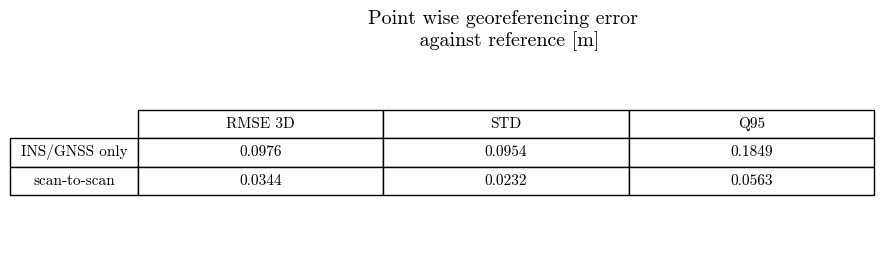

In [17]:
plot_georef_statistics_tables_compact(summaries)

## Plot point wise georeferencing errors

In [1]:
import laspy
import numpy as np

las = laspy.read("/media/b085164/Elements/PCD_SAM/Georef_v6_full/georef_errors/rmse_ref_w_chunk2chunk.las")

print(las.point_format.extra_dimension_names)

rmse = las["e3d"]  # ou le nom exact de ton extrabyte
x = las.x
y = las.y
z = las.z

<generator object PointFormat.extra_dimension_names.<locals>.<genexpr> at 0x7ba6ef4dedd0>


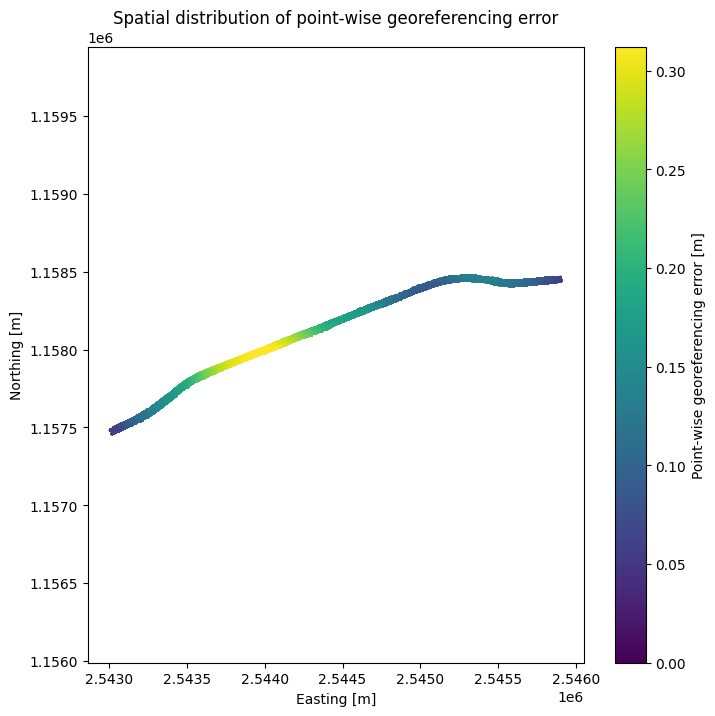

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

sc = plt.scatter(
    x, y,
    c=rmse,
    s=1,
    cmap="viridis",
    vmin=0,
    vmax=np.percentile(rmse,95)
)

plt.colorbar(sc,label="Point-wise georeferencing error [m]")
plt.xlabel("Easting [m]")
plt.ylabel("Northing [m]")
plt.title("Spatial distribution of point-wise georeferencing error")

plt.axis("equal")
plt.show()